# 📊 Data Processing — Student Placement Dataset

Este notebook realiza o pré-processamento do dataset sintético de colocação de estudantes (`student_placement_synthetic.csv`).

## Objetivo
Preparar os dados brutos para uso em modelos de Machine Learning, cobrindo:
1. **Carregamento** do dataset
2. **Encoding** de variáveis categóricas
3. **Imputação** de valores ausentes
4. **Exportação** do dataset processado
5. **Modelagem** com Gradient Boosting + K-Fold Cross-Validation

---

## 1. Importação das Bibliotecas

Importamos as bibliotecas essenciais para manipulação de dados (`pandas`, `numpy`) e visualização (`matplotlib`).

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## 2. Carregamento do Dataset

O dataset é lido a partir do arquivo CSV. As colunas `branch` e `college_tier` são forçadas para o tipo `object` (string) para garantir que sejam tratadas como categóricas, independentemente de eventuais valores numéricos presentes.

Uma cópia (`df`) é criada para preservar os dados originais em `dataset`.

In [28]:
dataset = pd.read_csv('student_placement_synthetic.csv', dtype={'branch': 'object', 'college_tier': 'object'})
df = dataset.copy()

## 3. Encoding das Variáveis Categóricas

Modelos de Machine Learning exigem entradas numéricas. Para isso, cada variável categórica recebe o tratamento adequado ao seu tipo:

### 3.1 `branch` → OneHotEncoder
A coluna `branch` representa o curso do estudante (ex: CS, IT, ECE). Trata-se de uma variável **nominal** — sem relação de ordem entre as categorias.

Usar `LabelEncoder` introduziria uma ordem artificial (ex: CS=0 < IT=1 < ECE=2), enganando o modelo. O `OneHotEncoder` é a escolha correta, criando uma coluna binária para cada categoria.

- `drop='first'`: remove a primeira categoria para evitar **multicolinearidade** (*dummy variable trap*).
- `sparse_output=False`: retorna array denso, compatível com pandas.

### 3.2 `college_tier` → LabelEncoder
A coluna `college_tier` representa a qualidade da instituição (Tier 1, Tier 2, Tier 3). Trata-se de uma variável **ordinal** — existe uma hierarquia natural: Tier 1 > Tier 2 > Tier 3.

O `LabelEncoder` é adequado aqui, pois a codificação numérica preserva essa ordem.



In [29]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# --- 3.1 OneHotEncoder para 'branch' (variável nominal, sem ordem) ---
ohe = OneHotEncoder(drop='first', sparse_output=False)
branch_encoded = ohe.fit_transform(df[['branch']])
branch_cols = ohe.get_feature_names_out(['branch'])
df_branch = pd.DataFrame(branch_encoded, columns=branch_cols, index=df.index)

# --- 3.2 LabelEncoder para 'college_tier' (variável ordinal: Tier 1 > Tier 2 > Tier 3) ---
le = LabelEncoder()
df['college_tier'] = le.fit_transform(df['college_tier'])

# Remove a coluna original 'branch' e concatena as colunas OHE ao DataFrame
df = df.drop(columns=['branch'])
df = pd.concat([df_branch, df], axis=1)

print('Colunas geradas pelo OHE:', list(branch_cols))
df.head()


Colunas geradas pelo OHE: ['branch_CSE', 'branch_Chemical', 'branch_ECE', 'branch_EE', 'branch_IT', 'branch_ME']


,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME,college_tier,cgpa,backlogs,coding_skills,...,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,0.0,0.0,1.0,0.0,0.0,0.0,2,6.70,0,7.6,...,6.4,0.3,1,4,4,3,2,1,1,14.75
1,0.0,1.0,0.0,0.0,0.0,0.0,1,5.70,0,5.4,...,6.3,1.9,0,4,0,0,0,0,0,NaN
2,0.0,0.0,0.0,1.0,0.0,0.0,1,7.19,0,5.6,...,4.4,5.2,1,3,2,1,2,0,1,19.06
3,0.0,0.0,0.0,0.0,0.0,0.0,1,6.48,0,5.2,...,1.1,6.7,1,4,3,0,0,0,0,NaN
4,1.0,0.0,0.0,0.0,0.0,0.0,1,6.71,1,5.9,...,2.7,2.8,1,2,0,3,0,1,1,13.42


## 5. Exportação do Dataset Processado

O DataFrame final, com todas as transformações aplicadas, é salvo em disco como `student_placement_processed.csv`.

- `index=False`: evita que o índice do pandas seja gravado como uma coluna extra no arquivo.

Este arquivo será utilizado como entrada pelos notebooks de treinamento dos modelos de ML.

In [30]:
df.to_csv('student_placement_processed.csv', index=False)

---

## 6. Modelagem — Gradient Boosting com K-Fold Cross-Validation

Com o dataset processado, aplicamos um pipeline de Machine Learning para prever `placement_status` (0 = não colocado, 1 = colocado).

### Por que Gradient Boosting?
O **Gradient Boosting** é um ensemble que treina árvores de decisão **sequencialmente**, onde cada nova árvore corrige os erros da anterior. É conhecido por:
- Alta acurácia mesmo sem tuning extenso
- Boa tolerância a features de escalas diferentes
- Interpretabilidade via `feature_importances_`

### Por que K-Fold Cross-Validation?
Em vez de um único split treino/teste (que pode ser enviesado), o **K-Fold** divide os dados em `k` partes (*folds*). O modelo é treinado `k` vezes, cada vez usando um fold diferente como teste. Isso:
- Garante que **todo dado seja usado para teste** exatamente uma vez
- Fornece uma estimativa mais **robusta e confiável** do desempenho real

Usamos `StratifiedKFold` (ao invés de `KFold` simples) para garantir que **a proporção de classes** (colocados vs. não colocados) seja preservada em cada fold.

### 6.1 Separação de Features (X) e Target (y)

- **Target (`y`)**: `placement_status` — o que queremos prever
- **Features (`X`)**: todas as demais colunas, **exceto `salary_package_lpa`**

A remoção de `salary_package_lpa` é **obrigatória**: o salário só existe se o estudante foi colocado, então incluí-lo causaria **data leakage** — o modelo aprenderia a fazer batota, não a generalizar.

In [31]:
df_model = pd.read_csv('student_placement_processed.csv')

# salary_package_lpa removida para evitar data leakage
X = df_model.drop(columns=['placement_status', 'salary_package_lpa'])
y = df_model['placement_status']

print(f'Features (X): {X.shape[1]} colunas, {X.shape[0]} amostras')
print(f'Target  (y): distribuição\n{y.value_counts(normalize=True).rename({0: "Não Colocado", 1: "Colocado"}).map("{:.1%}".format)}')

Features (X): 21 colunas, 100000 amostras
Target  (y): distribuição
placement_status
Colocado        68.5%
Não Colocado    31.5%
Name: proportion, dtype: str


### 6.2 Configuração do Modelo e do K-Fold

Parâmetros do `GradientBoostingClassifier`:

| Parâmetro | Valor | Descrição |
|---|---|---|
| `n_estimators` | 200 | Número de árvores sequenciais |
| `learning_rate` | 0.1 | Peso de cada árvore (shrinkage) |
| `max_depth` | 4 | Profundidade máxima por árvore |
| `subsample` | 0.8 | Fração do dataset por iteração (Stochastic GB) |
| `random_state` | 42 | Reprodutibilidade |

In [32]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Modelo
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

# K-Fold estratificado (5 folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Modelo e K-Fold configurados.')

Modelo e K-Fold configurados.


### 6.3 Execução do Cross-Validation

O `cross_validate` treina e avalia o modelo automaticamente nos 5 folds, calculando as métricas para cada um:

- **Accuracy**: % de predições corretas (geral)
- **Precision**: dos que o modelo prediz como colocados, quantos realmente são?
- **Recall**: dos estudantes realmente colocados, quantos o modelo acertou?
- **F1-Score**: média harmônica entre Precision e Recall
- **ROC-AUC**: capacidade do modelo de discriminar entre as duas classes

In [33]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = cross_validate(
    gb, X, y,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1  # usa todos os núcleos disponíveis
)

print('Cross-Validation concluído!')

Cross-Validation concluído!


### 6.4 Resultados por Fold e Média Final

In [34]:
metrics = {
    'Accuracy':  results['test_accuracy'],
    'Precision': results['test_precision'],
    'Recall':    results['test_recall'],
    'F1-Score':  results['test_f1'],
    'ROC-AUC':   results['test_roc_auc'],
}

print(f"{'Métrica':<12} {'Fold1':>7} {'Fold2':>7} {'Fold3':>7} {'Fold4':>7} {'Fold5':>7} {'Média':>7} {'±Std':>7}")
print("-" * 72)
for name, values in metrics.items():
    fold_str = "  ".join(f"{v:.4f}" for v in values)
    print(f"{name:<12}  {fold_str}  {values.mean():.4f}  {values.std():.4f}")

# Resumo em DataFrame
summary = pd.DataFrame({
    name: {'Média': vals.mean(), 'Desvio Padrão': vals.std()}
    for name, vals in metrics.items()
}).T
summary

Métrica        Fold1   Fold2   Fold3   Fold4   Fold5   Média    ±Std
------------------------------------------------------------------------
Accuracy      0.6989  0.6962  0.6990  0.6966  0.6980  0.6978  0.0012
Precision     0.7182  0.7172  0.7171  0.7175  0.7163  0.7172  0.0006
Recall        0.9223  0.9187  0.9258  0.9187  0.9254  0.9222  0.0031
F1-Score      0.8075  0.8055  0.8082  0.8057  0.8076  0.8069  0.0011
ROC-AUC       0.6825  0.6820  0.6768  0.6781  0.6868  0.6812  0.0035


,Média,Desvio Padrão
Accuracy,0.697760,0.001176
Precision,0.717235,0.000596
Recall,0.922176,0.003121
F1-Score,0.806893,0.001085
ROC-AUC,0.681240,0.003545


### 6.5 Feature Importance

Após treinar o modelo no dataset completo, extraímos a importância de cada feature segundo o Gradient Boosting.

Isso nos permite identificar quais variáveis mais influenciam a probabilidade de um estudante ser colocado.

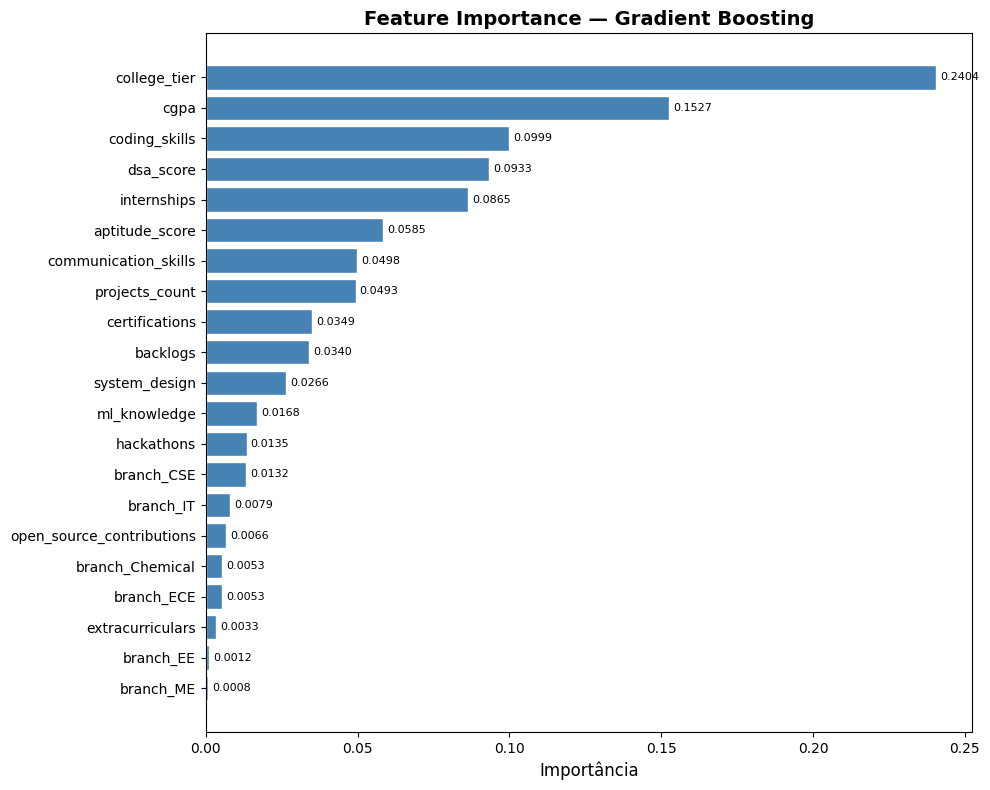


Top 5 features mais importantes:
college_tier     0.240448
cgpa             0.152694
coding_skills    0.099911
dsa_score        0.093339
internships      0.086462
dtype: float64


: 

In [ ]:
# Treina no dataset completo para extrair feature importances
gb.fit(X, y)

importances = pd.Series(gb.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances.index, importances.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Importância', fontsize=12)
ax.set_title('Feature Importance — Gradient Boosting', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

print('\nTop 5 features mais importantes:')
print(importances.sort_values(ascending=False).head())